In [64]:
import pandas as pd
import glob
from collections import Counter
from pvlib.solarposition import get_solarposition

In [65]:
all_csvs = glob.glob("big_one_2018/**/*.csv",recursive=True)
all_csvs[0]

'big_one_2018/2e8fcc3841698c643301d5e86571d863/697868_51.53_11.98_2018.csv'

In [66]:
import pandas as pd
import numpy as np
import healpy as hp
import glob
from pvlib.solarposition import get_solarposition
import pvlib # Added for comparison and dni_extra
import pytz # Added for timezone handling
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from tqdm import tqdm
import os
from datetime import datetime
import time # For timing comparison


# Configuration
NSIDE = 4  # HEALPix resolution
OUTPUT_FOLDER = "aggregated_results_claude_poa_comparison/"
LOCAL_TIMEZONE_STR = 'Etc/GMT-1' # UTC+1


def ensure_output_directory(path: str):
    """Create output directory if it doesn't exist."""
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Created output directory: {path}")

def extract_location_lot_lan_year_from_filename(filename: str) -> str:
    """Extract location ID from filename (e.g., 676147_47.25_11.38_2018.csv -> 676147)."""
    location, lat, long, year =  os.path.basename(filename).replace(".csv","").split("_")
    return  location, lat, long, year 



# --- 1. Data Loading (Simplified for single file) ---

def load_prepare_single_csv(file_path: str, local_tz_str: str) -> Optional[pd.DataFrame]:
    """Loads and prepares data from a single CSV file."""
    try:
        location, lat, long, year = extract_location_lot_lan_year_from_filename(file_path.split("/")[-1])
        # Read metadata first (optional, but good practice)
        meta = pd.read_csv(file_path, nrows=1).iloc[0]
        print("--- Metadata Summary ---")
        print(f"Location ID: {meta['Location ID']}")
        print(f"Coordinates: Lat={meta['Latitude']}, Lon={meta['Longitude']}")
        print(f"Elevation: {meta['Elevation']}m")
        print("-" * 22)

        # Read the actual data
        df = pd.read_csv(file_path, skiprows=2)

        # Robust datetime creation and timezone handling
        df['time_local'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])
        local_tz = pytz.timezone(local_tz_str)
        df['time_local'] = df['time_local'].dt.tz_localize(local_tz, ambiguous='infer', nonexistent='shift_forward')
        df['time_utc'] = df['time_local'].dt.tz_convert('UTC')
        df = df.set_index('time_utc')

        # Rename columns
        df.rename(columns={
            'DHI': 'dhi', 'GHI': 'ghi', 'DNI': 'dni',
            'Solar Zenith Angle': 'zenith_provided' # Keep for reference if needed
        }, inplace=True)

        # Ensure numeric types and fill NaNs (important!)
        numeric_cols = ['dhi', 'ghi', 'dni']
        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df[numeric_cols] = df[numeric_cols].fillna(0)

        print(f"Loaded {len(df)} hourly data points.")
        print(f"Time range: {df.index.min()} to {df.index.max()}")
        return df

    except FileNotFoundError:
        print(f"Error: CSV file not found at {file_path}")
        return None
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return None

# --- 2. HEALPix Utilities ---

def get_healpix_info(nside: int) -> Dict:
    """Get basic HEALPix grid information."""
    npix = hp.nside2npix(nside)
    pixel_solid_angle = hp.nside2pixarea(nside) # Steradians (sr)
    pixels = np.arange(npix)
    # Get angles in math convention (theta=colatitude, phi=azimuth E=0)
    theta_rad, phi_rad = hp.pix2ang(nside, pixels, nest=False) # RING scheme
    elevation_rad = np.pi/2 - theta_rad # Elevation (rad)
    azimuth_rad_math = phi_rad # Azimuth (rad, math convention E=0)

    # Also provide navigation azimuth (N=0, E=90) for convenience
    azimuth_deg_nav = np.degrees((np.pi/2 - azimuth_rad_math) % (2*np.pi))

    # Calculate direction vectors (unit vectors pointing from origin to pixel center)
    # x = sin(theta)cos(phi), y = sin(theta)sin(phi), z = cos(theta) [standard physics spherical]
    # Or using elevation/azimuth_math: x=cos(el)cos(az_m), y=cos(el)sin(az_m), z=sin(el)
    # Let's use a common convention like X=East, Y=North, Z=Up
    # East = cos(el)sin(az_nav) -> cos(el)sin(90-az_m) -> cos(el)cos(az_m)
    # North = cos(el)cos(az_nav) -> cos(el)cos(90-az_m) -> cos(el)sin(az_m)
    # Up = sin(el)
    vec_x = np.cos(elevation_rad) * np.cos(azimuth_rad_math)
    vec_y = np.cos(elevation_rad) * np.sin(azimuth_rad_math)
    vec_z = np.sin(elevation_rad)
    direction_vectors = np.vstack((vec_x, vec_y, vec_z)).T # Shape (npix, 3)


    return {
        "nside": nside,
        "npix": npix,
        "pixel_solid_angle": pixel_solid_angle,
        "pixels": pixels,
        "theta_rad": theta_rad, # Co-latitude / Zenith (rad)
        "phi_rad": phi_rad,     # Azimuth Math (E=0) (rad)
        "elevation_rad": elevation_rad,
        "azimuth_rad_math": azimuth_rad_math,
        "azimuth_deg_nav": azimuth_deg_nav, # Azimuth Nav (N=0, E=90) (deg)
        "direction_vectors": direction_vectors # Unit vectors to pixel centers
    }

def azimuth_elevation_to_healpix_pixel(azimuth_rad_math: float, elevation_rad: float, nside: int) -> Optional[int]:
    """
    Convert azimuth (math, E=0) and elevation (radians) to the nearest HEALPix pixel index.
    Handles potential numerical inaccuracies by clipping theta. Returns None if inputs are invalid.
    """
    if not np.isfinite(azimuth_rad_math) or not np.isfinite(elevation_rad):
        return None
    if elevation_rad < -np.pi/2 or elevation_rad > np.pi/2: # Check elevation bounds
         return None

    theta = np.pi/2 - elevation_rad # Co-latitude
    phi = azimuth_rad_math % (2 * np.pi) # Ensure phi in [0, 2pi)

    # Clip theta slightly inside [0, pi] for numerical stability near poles
    theta = np.clip(theta, 1e-9, np.pi - 1e-9)

    try:
        # Use nest=False for RING scheme consistently
        pixel = hp.ang2pix(nside, theta, phi, nest=False)
        return int(pixel)
    except Exception as e:
        print(f"Error in hp.ang2pix: {e}. Inputs: nside={nside}, theta={theta:.4f}, phi={phi:.4f}")
        return None

# --- 3. Sky Radiance Calculation (Revised) ---

def calculate_isotropic_diffuse_radiance(dhi: float, nside: int, hp_info: Dict) -> Tuple[np.ndarray, np.ndarray]:
    """
    Distributes DHI isotropically over the sky hemisphere.
    Isotropic radiance L = DHI / pi.

    Returns:
        Tuple[np.ndarray, np.ndarray]:
            - Indices of visible pixels (elevation > 0).
            - Isotropic diffuse radiance values for visible pixels (W/m²/sr).
    """
    if dhi <= 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    elevation_rad = hp_info['elevation_rad']
    pixels = hp_info['pixels']

    # Select only pixels strictly above the horizon
    visible_mask = elevation_rad > 1e-6 # Use small threshold
    visible_pixels = pixels[visible_mask]

    if len(visible_pixels) == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    # For isotropic model, radiance is constant across the sky dome
    isotropic_radiance = dhi / np.pi # W/m²/sr

    diffuse_radiance_values = np.full(len(visible_pixels), isotropic_radiance)

    return visible_pixels, diffuse_radiance_values

def calculate_timestep_radiance_map(row: pd.Series, nside: int, hp_info: Dict) -> np.ndarray:
    """
    Calculates the sky radiance map (W/m²/sr) for a single timestep using
    isotropic diffuse and adding direct beam. Requires solar position
    ('zenith', 'azimuth' in degrees) in the row.

    Returns:
        np.ndarray: Sky radiance map for the timestep (W/m²/sr).
    """
    npix = hp_info['npix']
    pixel_solid_angle = hp_info['pixel_solid_angle']
    radiance_map = np.zeros(npix)

    # Check necessary inputs
    if pd.isna(row['dhi']) or pd.isna(row['dni']) or pd.isna(row['zenith']) or pd.isna(row['azimuth']):
        return radiance_map # Return zero map if data missing

    # 1. Diffuse Component (Isotropic)
    dhi = max(0, row['dhi']) # Ensure non-negative
    if dhi > 0:
        visible_pixels, diffuse_radiance = calculate_isotropic_diffuse_radiance(dhi, nside, hp_info)
        if len(visible_pixels) > 0:
            radiance_map[visible_pixels] += diffuse_radiance

    # 2. Direct Component
    dni = max(0, row['dni']) # Ensure non-negative
    solar_zenith_deg = row['zenith']

    # Add DNI only if sun is above the horizon
    if dni > 0 and solar_zenith_deg < 90:
        solar_elevation_rad = np.radians(90.0 - solar_zenith_deg)
        solar_azimuth_deg = row['azimuth'] # pvlib azimuth: N=0, E=90

        # Convert solar azimuth (N=0, E=90) to math convention (E=0, N=90)
        solar_azimuth_rad_math = np.radians((90.0 - solar_azimuth_deg) % 360.0)

        # Get sun pixel index
        sun_pixel = azimuth_elevation_to_healpix_pixel(solar_azimuth_rad_math, solar_elevation_rad, nside)

        if sun_pixel is not None:
            # Add DNI radiance to the sun pixel
            if pixel_solid_angle > 1e-12: # Avoid division by zero
                dni_radiance = dni / pixel_solid_angle # W/m²/sr
                radiance_map[sun_pixel] += dni_radiance
            else:
                 print(f"Warning: Pixel solid angle zero/small for nside={nside}")
    return radiance_map

# --- 4. Tilted Surface Calculation using HEALPix Map ---

def precompute_surface_geometry(surface_tilt_deg: float, surface_azimuth_deg: float, hp_info: Dict) -> Dict:
    """Precomputes geometry needed for POA calculation from HEALPix maps."""
    nside = hp_info['nside']
    npix = hp_info['npix']
    pixel_vectors = hp_info['direction_vectors'] # Shape (npix, 3) [East, North, Up] convention
    pixel_solid_angle = hp_info['pixel_solid_angle']
    elevation_rad = hp_info['elevation_rad']

    # Calculate surface normal vector in East, North, Up coordinates
    tilt_rad = np.radians(surface_tilt_deg)
    azimuth_rad_nav = np.radians(surface_azimuth_deg) # N=0, E=90

    # Normal vector components (pointing away from the collecting surface)
    # See e.g., https://pvpmc.sandia.gov/modeling-steps/1-weather-data/plane-of-array-poa-irradiance/poa-ground-reflected/
    # Or derive using rotations. A common formula:
    nx = np.sin(tilt_rad) * np.sin(azimuth_rad_nav) # East component
    ny = np.sin(tilt_rad) * np.cos(azimuth_rad_nav) # North component
    nz = np.cos(tilt_rad)                         # Up component
    surface_normal = np.array([nx, ny, nz])
    surface_normal /= np.linalg.norm(surface_normal) # Ensure unit vector

    # Calculate cosine of Angle of Incidence (AOI) for each HEALPix pixel
    # cos(AOI) = surface_normal ⋅ pixel_vector
    # Clip results between 0 and 1 (cos(AOI) cannot be > 1, ignore angles > 90 deg)
    cos_aoi = np.dot(pixel_vectors, surface_normal)
    cos_aoi = np.clip(cos_aoi, 0, 1) # Interested only in pixels hitting the front face (cos_aoi > 0)

    # Identify pixels visible to the surface (cos_aoi > 0) and above horizon (elevation > 0)
    sky_mask = (elevation_rad > 1e-6) & (cos_aoi > 1e-9)
    visible_sky_pixels = hp_info['pixels'][sky_mask]

    # Precompute integration weights for visible sky pixels
    sky_integration_weights = cos_aoi[sky_mask] * pixel_solid_angle

    return {
        "surface_normal": surface_normal,
        "cos_aoi": cos_aoi, # For all pixels
        "visible_sky_pixels": visible_sky_pixels,
        "sky_integration_weights": sky_integration_weights,
        "tilt_rad": tilt_rad
    }


def calculate_poa_from_healpix(row: pd.Series, nside: int, hp_info: Dict, surface_geom: Dict, albedo: float) -> float:
    """
    Calculates the POA irradiance (W/m²) for a single timestep using the HEALPix radiance map.
    """
    # Check if essential data is present and valid
    if pd.isna(row['ghi']) or pd.isna(row['dhi']) or pd.isna(row['dni']) or pd.isna(row['zenith']) or pd.isna(row['azimuth']):
         return 0.0 # Cannot calculate if data missing
    if row['ghi'] < 0: # Skip if GHI is negative
         return 0.0

    # 1. Calculate Sky Radiance Map for this timestep
    sky_radiance_map = calculate_timestep_radiance_map(row, nside, hp_info)

    # 2. Integrate Sky Radiance over the Tilted Surface
    visible_sky_pixels = surface_geom['visible_sky_pixels']
    sky_integration_weights = surface_geom['sky_integration_weights']

    # Sum(L_sky * cos(AOI) * pixel_solid_angle) over visible sky pixels
    poa_sky = np.sum(sky_radiance_map[visible_sky_pixels] * sky_integration_weights)

    # 3. Calculate Ground Reflected Component (using standard isotropic formula)
    ghi = max(0, row['ghi']) # Ensure non-negative
    tilt_rad = surface_geom['tilt_rad']
    poa_ground = ghi * albedo * (1.0 - np.cos(tilt_rad)) / 2.0

    # 4. Total POA Irradiance
    total_poa = poa_sky + poa_ground

    # Ensure non-negative result
    return max(0.0, total_poa)


In [67]:
print(load_prepare_single_csv("big_one_2017/82fbbe844b1b8c32054bdb443faf766a/452908_52.37_4.26_2017.csv",local_tz_str=LOCAL_TIMEZONE_STR))

--- Metadata Summary ---
Location ID: 452908
Coordinates: Lat=52.37, Lon=4.26
Elevation: 0m
----------------------
Loaded 8760 hourly data points.
Time range: 2016-12-31 23:30:00+00:00 to 2017-12-31 22:30:00+00:00
                           Year  Month  Day  Hour  Minute  dhi  ghi  dni  \
time_utc                                                                   
2016-12-31 23:30:00+00:00  2017      1    1     0      30    0    0    0   
2017-01-01 00:30:00+00:00  2017      1    1     1      30    0    0    0   
2017-01-01 01:30:00+00:00  2017      1    1     2      30    0    0    0   
2017-01-01 02:30:00+00:00  2017      1    1     3      30    0    0    0   
2017-01-01 03:30:00+00:00  2017      1    1     4      30    0    0    0   
...                         ...    ...  ...   ...     ...  ...  ...  ...   
2017-12-31 18:30:00+00:00  2017     12   31    19      30    0    0    0   
2017-12-31 19:30:00+00:00  2017     12   31    20      30    0    0    0   
2017-12-31 20:30:00+00:00 

In [ ]:
from concurrent.futures import ProcessPoolExecutor
import os
from typing import Optional, List, Dict, Tuple
import pandas as pd
import numpy as np
from tqdm import tqdm
import time
from calendar import monthrange

def process_single_file(input_csv: str, 
                       output_folder: str, 
                       local_tz_str: str,
                       nside: int = 4,
                       surface_tilt_deg: float = 30.0,  # Example tilted surface (30° tilt)
                       surface_azimuth_deg: float = 180.0,  # Example: facing south
                       albedo: float = 0.2) -> bool:
    """
    Process a single CSV file and save results (both monthly and yearly).
    Returns True if successful, False otherwise.
    """
    try:
        location, lat, long, year = extract_location_lot_lan_year_from_filename(os.path.basename(input_csv))
        
        # Load and prepare data
        print(f"\nProcessing: {input_csv}")
        df = load_prepare_single_csv(input_csv, local_tz_str)
        if df is None:
            return False
        
        # Calculate solar position for all timestamps
        solpos = get_solarposition(df.index, float(lat), float(long))
        df['zenith'] = solpos['apparent_zenith']
        df['azimuth'] = solpos['azimuth']
        
        # Get HEALPix info and precompute surface geometry
        hp_info = get_healpix_info(nside)
        surface_geom = precompute_surface_geometry(surface_tilt_deg, surface_azimuth_deg, hp_info)
        
        # Process each month and accumulate yearly data
        yearly_radiance_accumulator = np.zeros(hp_info['npix'])
        yearly_sun_occurrences = np.zeros(hp_info['npix'], dtype=int)
        yearly_daylight_timesteps = 0
        yearly_ghi_sum = 0
        yearly_poa_sum = 0
        
        # Get unique months from the data
        unique_months = df.index.month.unique()
        
        for month in unique_months:
            # Filter for this month
            df_month = df[df.index.month == month]
            
            # Filter for daylight hours
            daylight_mask = df_month['zenith'] < 90
            df_daylight = df_month[daylight_mask]
            
            if len(df_daylight) == 0:
                print(f"No daylight hours found for month {month}")
                continue
            
            # Calculate POA irradiance for each timestep
            poa_results = []
            for idx, row in df_daylight.iterrows():
                poa = calculate_poa_from_healpix(row, nside, hp_info, surface_geom, albedo)
                poa_results.append(poa)
            
            # Calculate monthly aggregates
            total_ghi = df_daylight['ghi'].sum()
            avg_ghi_daylight = df_daylight['ghi'].mean()
            avg_dhi_daylight = df_daylight['dhi'].mean()
            avg_dni_daylight = df_daylight['dni'].mean()
            avg_poa = np.mean(poa_results)
            
            # Create monthly skymap data (average radiance per pixel during daylight)
            radiance_accumulator = np.zeros(hp_info['npix'])
            sun_occurrences = np.zeros(hp_info['npix'], dtype=int)
            
            for idx, row in df_daylight.iterrows():
                radiance_map = calculate_timestep_radiance_map(row, nside, hp_info)
                radiance_accumulator += radiance_map
                
                # Track sun position occurrences
                if row['dni'] > 0 and row['zenith'] < 90:
                    solar_elevation_rad = np.radians(90.0 - row['zenith'])
                    solar_azimuth_rad_math = np.radians((90.0 - row['azimuth']) % 360.0)
                    sun_pixel = azimuth_elevation_to_healpix_pixel(solar_azimuth_rad_math, solar_elevation_rad, nside)
                    if sun_pixel is not None:
                        sun_occurrences[sun_pixel] += 1
            
            # Average radiance for month
            average_radiance = radiance_accumulator / len(df_daylight)
            
            # Accumulate yearly data
            yearly_radiance_accumulator += radiance_accumulator
            yearly_sun_occurrences += sun_occurrences
            yearly_daylight_timesteps += len(df_daylight)
            yearly_ghi_sum += total_ghi
            yearly_poa_sum += sum(poa_results)
            
            # Create monthly metadata
            month_str = str(month).zfill(2)
            metadata = {
                'nside': nside,
                'latitude': float(lat),
                'longitude': float(long),
                'total_timesteps_in_period': len(df_month),
                'valid_timesteps_for_aggregation': len(df_month),
                'daylight_timesteps_processed': len(df_daylight),
                'total_ghi_period': total_ghi,
                'average_ghi_daylight': avg_ghi_daylight,
                'average_dhi_daylight': avg_dhi_daylight,
                'average_dni_daylight': avg_dni_daylight,
                'average_poa_daylight': avg_poa,
                'max_average_radiance': np.max(average_radiance),
                'pixel_solid_angle': hp_info['pixel_solid_angle'],
                'surface_tilt_deg': surface_tilt_deg,
                'surface_azimuth_deg': surface_azimuth_deg,
                'albedo': albedo,
                'location_id': location,
                'period': 'monthly',
                'start_date': df_month.index[0].isoformat(),
                'end_date': df_month.index[-1].isoformat()
            }
            
            # Get azimuth and elevation for each pixel
            azimuth_deg_nav = hp_info['azimuth_deg_nav']
            elevation_deg = np.degrees(hp_info['elevation_rad'])
            
            # Create monthly skymap dataframe
            skymap_data = pd.DataFrame({
                'healpix_pixel_id': hp_info['pixels'],
                'azimuth_nav_deg': np.round(azimuth_deg_nav, 2),
                'elevation_deg': np.round(elevation_deg, 2),
                'average_radiance_W_m2_sr': np.round(average_radiance, 3),
                'sun_occurrences': sun_occurrences
            })
            
            # Save monthly results
            metadata_filename = f"{location}_{year}_{month_str}_metadata.csv"
            skymap_filename = f"{location}_{year}_{month_str}_skymap.csv"
            
            metadata_path = os.path.join(output_folder, metadata_filename)
            skymap_path = os.path.join(output_folder, skymap_filename)
            
            pd.DataFrame([metadata]).to_csv(metadata_path, index=False)
            skymap_data.to_csv(skymap_path, index=False)
        
        # Create yearly aggregates
        if yearly_daylight_timesteps > 0:
            yearly_average_radiance = yearly_radiance_accumulator / yearly_daylight_timesteps
            yearly_avg_ghi = yearly_ghi_sum / yearly_daylight_timesteps
            yearly_avg_poa = yearly_poa_sum / yearly_daylight_timesteps
            
            # Calculate yearly averages for DHI and DNI
            daylight_mask_year = df['zenith'] < 90
            df_daylight_year = df[daylight_mask_year]
            yearly_avg_dhi = df_daylight_year['dhi'].mean()
            yearly_avg_dni = df_daylight_year['dni'].mean()
            
            # Create yearly metadata
            yearly_metadata = {
                'nside': nside,
                'latitude': float(lat),
                'longitude': float(long),
                'total_timesteps_in_period': len(df),
                'valid_timesteps_for_aggregation': len(df),
                'daylight_timesteps_processed': yearly_daylight_timesteps,
                'total_ghi_period': yearly_ghi_sum,
                'average_ghi_daylight': yearly_avg_ghi,
                'average_dhi_daylight': yearly_avg_dhi,
                'average_dni_daylight': yearly_avg_dni,
                'average_poa_daylight': yearly_avg_poa,
                'max_average_radiance': np.max(yearly_average_radiance),
                'pixel_solid_angle': hp_info['pixel_solid_angle'],
                'surface_tilt_deg': surface_tilt_deg,
                'surface_azimuth_deg': surface_azimuth_deg,
                'albedo': albedo,
                'location_id': location,
                'period': 'yearly',
                'start_date': df.index[0].isoformat(),
                'end_date': df.index[-1].isoformat()
            }
            
            # Create yearly skymap dataframe
            yearly_skymap_data = pd.DataFrame({
                'healpix_pixel_id': hp_info['pixels'],
                'azimuth_nav_deg': np.round(azimuth_deg_nav, 2),
                'elevation_deg': np.round(elevation_deg, 2),
                'average_radiance_W_m2_sr': np.round(yearly_average_radiance, 3),
                'sun_occurrences': yearly_sun_occurrences
            })
            
            # Save yearly results
            yearly_metadata_filename = f"{location}_{year}_yearly_metadata.csv"
            yearly_skymap_filename = f"{location}_{year}_yearly_skymap.csv"
            
            yearly_metadata_path = os.path.join(output_folder, yearly_metadata_filename)
            yearly_skymap_path = os.path.join(output_folder, yearly_skymap_filename)
            
            pd.DataFrame([yearly_metadata]).to_csv(yearly_metadata_path, index=False)
            yearly_skymap_data.to_csv(yearly_skymap_path, index=False)
        
        print(f"Successfully processed {input_csv}")
        return True
        
    except Exception as e:
        print(f"Error processing {input_csv}: {str(e)}")
        import traceback
        traceback.print_exc()
        return False

def process_multiple_csvs(csv_list: List[str], 
                         output_folder: str,
                         local_tz_str: str,
                         max_workers: int = 4,
                         limit: Optional[int] = None) -> None:
    """
    Process multiple CSV files in parallel.
    """
    ensure_output_directory(output_folder)
    
    # Apply limit if specified
    if limit is not None:
        csv_list = csv_list[:limit]
        print(f"Processing limited to {limit} files for testing.")
    
    print(f"Starting to process {len(csv_list)} files with {max_workers} workers...")
    start_time = time.time()
    
    # Process files in parallel
    success_count = 0
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = []
        for csv_path in csv_list:
            future = executor.submit(process_single_file, csv_path, output_folder, local_tz_str)
            futures.append(future)
        
        # Wait for all futures and count successes
        for future in tqdm(futures, desc="Overall progress"):
            if future.result():
                success_count += 1
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    print(f"\nProcessing complete!")
    print(f"Successfully processed: {success_count}/{len(csv_list)} files")
    print(f"Total time: {elapsed_time:.2f} seconds")
    print(f"Average time per file: {elapsed_time/len(csv_list):.2f} seconds")

# Main execution code
if __name__ == "__main__":
    # Configuration
    OUTPUT_FOLDER = "aggregated_results_claude_poa_comparison/"
    LOCAL_TIMEZONE_STR = 'Etc/GMT-1'  # UTC+1
    
    # Get all CSV files from the directory
    all_csvs = glob.glob("big_one_2018/**/*.csv", recursive=True)
    
    # Process limited set for testing (set to None to process all)
    TEST_LIMIT = None  # Process only 2 files for testing, set to None for full run
    
    # Process the files
    process_multiple_csvs(
        csv_list=all_csvs,
        output_folder=OUTPUT_FOLDER,
        local_tz_str=LOCAL_TIMEZONE_STR,
        max_workers=8,  # Adjust based on your CPU cores
        limit=TEST_LIMIT
    )

Loading skymap and metadata from aggregated_results_claude_poa_comparison/697868_2018_yearly_skymap.csv and aggregated_results_claude_poa_comparison/697868_2018_yearly_metadata.csv
Loading original time series from big_one_2018/2e8fcc3841698c643301d5e86571d863/697768_55.53_11.98_2018.csv
--- Metadata Summary ---
Location ID: 697768
Coordinates: Lat=55.53, Lon=11.98
Elevation: 47m
----------------------
Loaded 8760 hourly data points.
Time range: 2017-12-31 23:30:00+00:00 to 2018-12-31 22:30:00+00:00
Calculating POA using direct tracing...


Direct tracing: 100%|█████████████████████| 4457/4457 [00:00<00:00, 6704.31it/s]


Calculating POA using skymap...


Skymap calculation: 100%|█████████████████| 4457/4457 [00:01<00:00, 2831.15it/s]


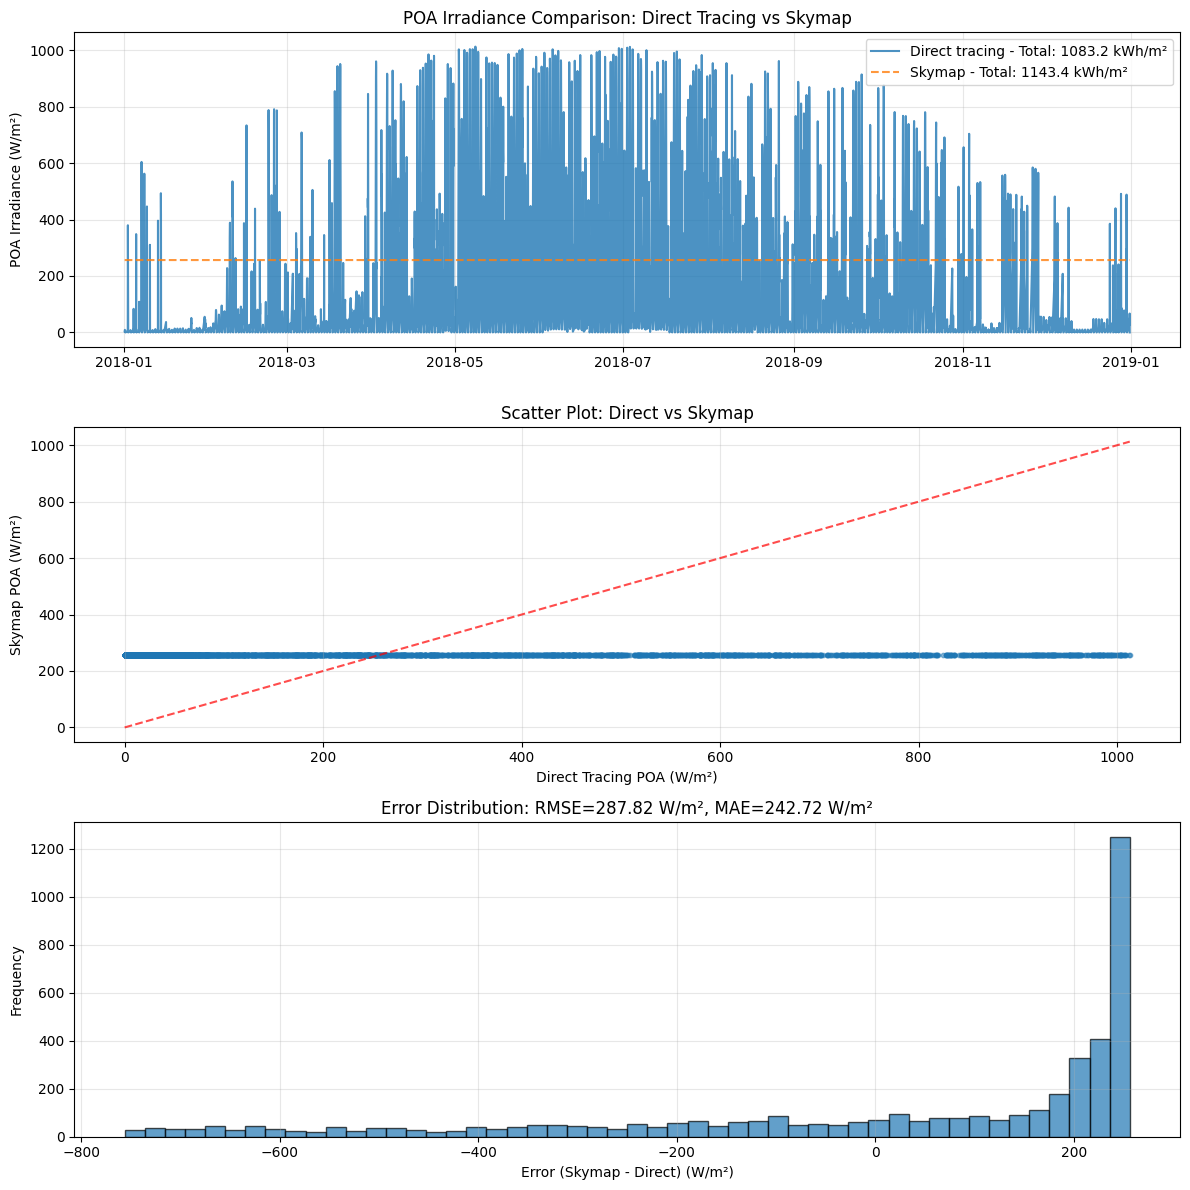


--- Comparison Summary ---
Total POA Energy (Direct): 1083.24 kWh/m²
Total POA Energy (Skymap): 1143.37 kWh/m²
Relative Error: 5.55%
RMSE: 287.82 W/m²
MAE: 242.72 W/m²
MBE: 13.49 W/m²


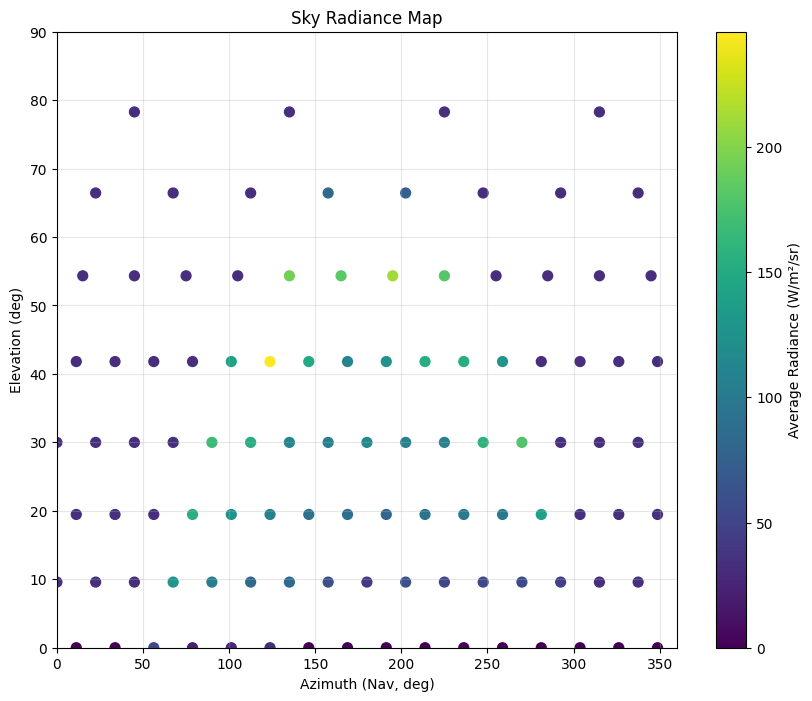

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from pvlib.solarposition import get_solarposition
import pytz
from typing import Tuple, Dict
import os
from tqdm import tqdm

def load_skymap_and_metadata(skymap_file: str, metadata_file: str) -> Tuple[pd.DataFrame, Dict]:
    """Load skymap and metadata CSVs generated by the processing code."""
    skymap_df = pd.read_csv(skymap_file)
    metadata_df = pd.read_csv(metadata_file)
    metadata_dict = metadata_df.iloc[0].to_dict()
    return skymap_df, metadata_dict

def reconstruct_healpix_info(nside: int) -> Dict:
    """Reconstruct HEALPix information that's needed for calculations."""
    npix = hp.nside2npix(nside)
    pixels = np.arange(npix)
    theta_rad, phi_rad = hp.pix2ang(nside, pixels, nest=False)
    elevation_rad = np.pi/2 - theta_rad
    azimuth_rad_math = phi_rad
    
    # Convert to navigation convention for reference
    azimuth_deg_nav = np.degrees((np.pi/2 - azimuth_rad_math) % (2*np.pi))
    
    # Direction vectors
    vec_x = np.cos(elevation_rad) * np.cos(azimuth_rad_math)
    vec_y = np.cos(elevation_rad) * np.sin(azimuth_rad_math)
    vec_z = np.sin(elevation_rad)
    direction_vectors = np.vstack((vec_x, vec_y, vec_z)).T
    
    return {
        "nside": nside,
        "npix": npix,
        "pixel_solid_angle": hp.nside2pixarea(nside),
        "pixels": pixels,
        "theta_rad": theta_rad,
        "phi_rad": phi_rad,
        "elevation_rad": elevation_rad,
        "azimuth_rad_math": azimuth_rad_math,
        "azimuth_deg_nav": azimuth_deg_nav,
        "direction_vectors": direction_vectors
    }

def compute_surface_geometry(surface_tilt_deg: float, surface_azimuth_deg: float, hp_info: Dict) -> Dict:
    """Compute surface geometry for POA calculations."""
    tilt_rad = np.radians(surface_tilt_deg)
    azimuth_rad_nav = np.radians(surface_azimuth_deg)
    
    # Surface normal vector
    nx = np.sin(tilt_rad) * np.sin(azimuth_rad_nav)
    ny = np.sin(tilt_rad) * np.cos(azimuth_rad_nav)
    nz = np.cos(tilt_rad)
    surface_normal = np.array([nx, ny, nz])
    surface_normal /= np.linalg.norm(surface_normal)
    
    # Calculate AOI for all pixels
    cos_aoi = np.dot(hp_info['direction_vectors'], surface_normal)
    cos_aoi = np.clip(cos_aoi, 0, 1)
    
    # Identify visible pixels
    elevation_rad = hp_info['elevation_rad']
    sky_mask = (elevation_rad > 1e-6) & (cos_aoi > 1e-9)
    visible_sky_pixels = hp_info['pixels'][sky_mask]
    
    # Integration weights
    sky_integration_weights = cos_aoi[sky_mask] * hp_info['pixel_solid_angle']
    
    return {
        "surface_normal": surface_normal,
        "cos_aoi": cos_aoi,
        "visible_sky_pixels": visible_sky_pixels,
        "sky_integration_weights": sky_integration_weights,
        "tilt_rad": tilt_rad
    }

def calculate_poa_from_skymap(skymap_df: pd.DataFrame, 
                             surface_geom: Dict, 
                             ghi: float,
                             albedo: float = 0.2) -> float:
    """
    Calculate POA from skymap data.
    
    Args:
        skymap_df: DataFrame with skymap data
        surface_geom: Surface geometry information
        ghi: Global horizontal irradiance for ground reflection
        albedo: Ground albedo coefficient
    
    Returns:
        POA irradiance in W/m²
    """
    # Extract radiance values for the visible pixels
    visible_pixels = surface_geom['visible_sky_pixels']
    visible_radiance = skymap_df.loc[skymap_df['healpix_pixel_id'].isin(visible_pixels), 'average_radiance_W_m2_sr'].values
    
    # Calculate sky component
    sky_weights = surface_geom['sky_integration_weights']
    poa_sky = np.sum(visible_radiance * sky_weights)
    
    # Calculate ground reflected component
    tilt_rad = surface_geom['tilt_rad']
    poa_ground = 0#ghi * albedo * (1.0 - np.cos(tilt_rad)) / 2.0
    
    # Total POA
    total_poa = poa_sky# + poa_ground
    
    return max(0.0, total_poa)

def compare_skydome_and_direct_tracing(skymap_file: str, 
                                     metadata_file: str,
                                     original_csv: str,
                                     surface_tilt: float = 30.0,
                                     surface_azimuth: float = 180.0,
                                     albedo: float = 0.2,
                                     timezone_str: str = 'Etc/GMT-1') -> None:
    """
    Compare POA irradiation calculated from skymap vs direct tracing.
    
    Args:
        skymap_file: Path to yearly skymap CSV
        metadata_file: Path to yearly metadata CSV
        original_csv: Path to original time series CSV
        surface_tilt: Surface tilt in degrees
        surface_azimuth: Surface azimuth in degrees (N=0, E=90)
        albedo: Ground albedo coefficient
        timezone_str: Local timezone string
    """
    print(f"Loading skymap and metadata from {skymap_file} and {metadata_file}")
    skymap_df, metadata = load_skymap_and_metadata(skymap_file, metadata_file)
    
    # Extract necessary metadata
    nside = int(metadata['nside'])
    latitude = metadata['latitude']
    longitude = metadata['longitude']
    altitude = metadata.get('altitude', 0)  # Default to 0 if not present
    
    print(f"Loading original time series from {original_csv}")
    # Load and prepare original data
    df = load_prepare_single_csv(original_csv, timezone_str)
    if df is None:
        print("Failed to load original CSV")
        return
    
    # Calculate solar position for all timestamps
    solpos = get_solarposition(df.index, latitude, longitude)
    df['zenith'] = solpos['apparent_zenith']
    df['azimuth'] = solpos['azimuth']
    
    # Filter to daylight hours only
    daylight_mask = df['zenith'] < 90
    df_daylight = df[daylight_mask]
    
    if len(df_daylight) == 0:
        print("No daylight hours found in the dataset")
        return
    
    # Reconstruct HEALPix info and surface geometry
    hp_info = reconstruct_healpix_info(nside)
    surface_geom = compute_surface_geometry(surface_tilt, surface_azimuth, hp_info)
    
    # Calculate POA using direct tracing (original method)
    print("Calculating POA using direct tracing...")
    poa_direct = []
    for idx, row in tqdm(df_daylight.iterrows(), total=len(df_daylight), desc="Direct tracing"):
        poa = calculate_poa_from_healpix(row, nside, hp_info, surface_geom, albedo)
        poa_direct.append(poa)
    
    # Calculate POA using skymap (assuming constant sky conditions throughout the year)
    print("Calculating POA using skymap...")
    poa_skymap = []
    for idx, row in tqdm(df_daylight.iterrows(), total=len(df_daylight), desc="Skymap calculation"):
        # Using average GHI during daylight from metadata
        avg_ghi = metadata['average_ghi_daylight']
        poa = calculate_poa_from_skymap(skymap_df, surface_geom, avg_ghi, albedo)
        poa_skymap.append(poa)
    
    # Convert to numpy arrays for plotting
    poa_direct = np.array(poa_direct)
    poa_skymap = np.array(poa_skymap)
    
    # Calculate comparison metrics
    rmse = np.sqrt(np.mean((poa_direct - poa_skymap) ** 2))
    mae = np.mean(np.abs(poa_direct - poa_skymap))
    mbe = np.mean(poa_skymap - poa_direct)
    relative_error = (poa_skymap.sum() - poa_direct.sum()) / poa_direct.sum() * 100
    
    # Create comparison plots
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))
    
    # Time series comparison
    ax1.plot(df_daylight.index, poa_direct, label=f'Direct tracing - Total: {poa_direct.sum()/1000:.1f} kWh/m²', alpha=0.8)
    ax1.plot(df_daylight.index, poa_skymap, label=f'Skymap - Total: {poa_skymap.sum()/1000:.1f} kWh/m²', alpha=0.8, linestyle='--')
    ax1.set_ylabel('POA Irradiance (W/m²)')
    ax1.set_title('POA Irradiance Comparison: Direct Tracing vs Skymap')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Scatter plot
    max_val = max(poa_direct.max(), poa_skymap.max())
    ax2.scatter(poa_direct, poa_skymap, alpha=0.5, s=10)
    ax2.plot([0, max_val], [0, max_val], 'r--', alpha=0.7)  # 1:1 line
    ax2.set_xlabel('Direct Tracing POA (W/m²)')
    ax2.set_ylabel('Skymap POA (W/m²)')
    ax2.set_title('Scatter Plot: Direct vs Skymap')
    ax2.grid(True, alpha=0.3)
    
    # Error histogram
    errors = poa_skymap - poa_direct
    ax3.hist(errors, bins=50, alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Error (Skymap - Direct) (W/m²)')
    ax3.set_ylabel('Frequency')
    ax3.set_title(f'Error Distribution: RMSE={rmse:.2f} W/m², MAE={mae:.2f} W/m²')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n--- Comparison Summary ---")
    print(f"Total POA Energy (Direct): {poa_direct.sum()/1000:.2f} kWh/m²")
    print(f"Total POA Energy (Skymap): {poa_skymap.sum()/1000:.2f} kWh/m²")
    print(f"Relative Error: {relative_error:.2f}%")
    print(f"RMSE: {rmse:.2f} W/m²")
    print(f"MAE: {mae:.2f} W/m²")
    print(f"MBE: {mbe:.2f} W/m²")
    
    # Plot the skymap itself for reference
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(skymap_df['azimuth_nav_deg'], 
                         skymap_df['elevation_deg'], 
                         c=skymap_df['average_radiance_W_m2_sr'], 
                         cmap='viridis', 
                         s=50)
    plt.colorbar(scatter, label='Average Radiance (W/m²/sr)')
    plt.xlabel('Azimuth (Nav, deg)')
    plt.ylabel('Elevation (deg)')
    plt.title('Sky Radiance Map')
    plt.xlim(0, 360)
    plt.ylim(0, 90)
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage:
if __name__ == "__main__":
    # Replace these with actual file paths
    skymap_file = "aggregated_results_claude_poa_comparison/697868_2018_yearly_skymap.csv"
    metadata_file = "aggregated_results_claude_poa_comparison/697868_2018_yearly_metadata.csv"
    original_csv = "big_one_2018/2e8fcc3841698c643301d5e86571d863/697768_55.53_11.98_2018.csv"
    
    # Run the comparison
    compare_skydome_and_direct_tracing(
        skymap_file=skymap_file,
        metadata_file=metadata_file,
        original_csv=original_csv,
        surface_tilt=30.0,
        surface_azimuth=180.0,
        albedo=0.2,
        timezone_str='Etc/GMT-1'
    )

In [57]:
#get_healpix_info(4)

In [52]:
!head big_one_2018/2e8fcc3841698c643301d5e86571d863/676147_47.25_11.38_2018.csv

Source,Location ID,City,State,Country,Latitude,Longitude,Time Zone,Elevation,Local Time Zone,Clearsky DHI Units,Clearsky DNI Units,Clearsky GHI Units,Dew Point Units,DHI Units,DNI Units,GHI Units,Solar Zenith Angle Units,Temperature Units,Pressure Units,Relative Humidity Units,Precipitable Water Units,Wind Direction Units,Wind Speed Units,Cloud Type -15,Cloud Type 0,Cloud Type 1,Cloud Type 2,Cloud Type 3,Cloud Type 4,Cloud Type 5,Cloud Type 6,Cloud Type 7,Cloud Type 8,Cloud Type 9,Cloud Type 10,Cloud Type 11,Cloud Type 12,Fill Flag 0,Fill Flag 1,Fill Flag 2,Fill Flag 3,Fill Flag 4,Fill Flag 5,Surface Albedo Units,Version
NSRDB,676147,-,-,-,47.25,11.38,0,666,1,w/m2,w/m2,w/m2,c,w/m2,w/m2,w/m2,Degree,c,mbar,%,cm,Degrees,m/s,N/A,Clear,Probably Clear,Fog,Water,Super-Cooled Water,Mixed,Opaque Ice,Cirrus,Overlapping,Overshooting,Unknown,Dust,Smoke,N/A,Missing Image,Low Irradiance,Exceeds Clearsky,Missing CLoud Properties,Rayleigh Violation,N/A,unknown
Year,Month,Day,Hour,Minute,DHI,GHI,DNI,Cl

In [53]:
!head aggregated_results_gemini_refactor/676147_2018_01_metadata.csv

nside,latitude,longitude,total_timesteps_in_period,valid_timesteps_for_aggregation,daylight_timesteps_processed,total_ghi_period,average_ghi_daylight,average_dhi_daylight,average_dni_daylight,max_average_radiance,pixel_solid_angle,location_id,period,start_date,end_date
4,47.25,11.38,744,744,273,37951,139.01465201465203,63.97069597069597,254.12454212454213,845.5039271317668,0.06544984694978735,676147,monthly,2018-01-01T00:30:00,2018-01-31T23:30:00


In [54]:
!head aggregated_results_gemini_refactor/676147_2018_01_skymap.csv

healpix_pixel_id,azimuth_nav_deg,elevation_deg,average_radiance_W_m2_sr,sun_occurrences
0,45.0,78.28,20.959,0
1,315.0,78.28,20.959,0
2,225.0,78.28,20.959,0
3,135.0,78.28,20.959,0
4,67.5,66.44,20.958,0
5,22.5,66.44,20.958,0
6,337.5,66.44,20.958,0
7,292.5,66.44,20.958,0
8,247.5,66.44,20.958,0
